# FOBI 1D Reconstruction Tutorial

This notebook demonstrates how to use the FOBI package for 1D neutron transmission spectrum reconstruction.

## Overview

FOBI (Full-spectrum Bragg edge transmission imaging) is a technique for reconstructing high-resolution neutron transmission spectra from chopper-modulated time-of-flight measurements. This tutorial shows the new object-oriented API with method chaining.

## Installation

```bash
pip install -e .
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import fobi

print(f"FOBI version: {fobi.__version__}")

FOBI version: 1.0.0


## 1. Generate Mock Data

Let's create synthetic data simulating a neutron transmission measurement with:
- A Bragg edge at around 4 Å (typical for iron)
- Chopper modulation
- Realistic noise

In [2]:
def generate_mock_data(L=9, tmax=10000, nrep=8, noise_std=0.02):
    """
    Generate mock neutron transmission data.
    
    Parameters
    ----------
    L : float
        Flight path length in meters
    tmax : float
        Maximum time-of-flight in microseconds
    nrep : int
        Number of chopper repetitions
    noise_std : float
        Standard deviation of Gaussian noise
    
    Returns
    -------
    t : np.ndarray
        Time-of-flight array
    signal : np.ndarray
        Sample signal with Bragg edge
    openbeam : np.ndarray
        Open beam (no sample)
    """
    # Time array with 1000 bins per repetition
    nbins = 1000 * nrep
    t = np.linspace(0, tmax, nbins)
    
    # Convert to wavelength: λ (Å) = 3.956 * t (ms) / L (m)
    wavelength = 3.956 * (t / 1000) / L
    
    # Create transmission spectrum with Bragg edge
    # Edge at λ = 4.05 Å (iron 110 reflection)
    edge_position = 4.05  # Angstroms
    edge_width = 0.15
    edge_height = 0.3
    
    # Sigmoid edge model
    transmission = 0.7 + edge_height / (1 + np.exp(-(wavelength - edge_position) / edge_width))
    
    # Add some texture (multiple edges)
    transmission += 0.05 * np.sin(wavelength * 3)
    
    # Open beam (constant with some variation)
    openbeam_base = np.ones_like(t) * 1000
    openbeam = openbeam_base + np.random.randn(len(t)) * noise_std * openbeam_base
    
    # Sample signal = transmission * openbeam
    signal_base = transmission * openbeam_base
    signal = signal_base + np.random.randn(len(t)) * noise_std * signal_base
    
    return t, signal, openbeam, transmission

# Generate data
L = 9  # meters
tmax = 10000  # microseconds
nrep = 8  # repetitions

t, signal, openbeam, true_transmission = generate_mock_data(L, tmax, nrep)

print(f"Generated {len(t)} data points")
print(f"Time range: {t[0]:.1f} - {t[-1]:.1f} µs")

Generated 8000 data points
Time range: 0.0 - 10000.0 µs


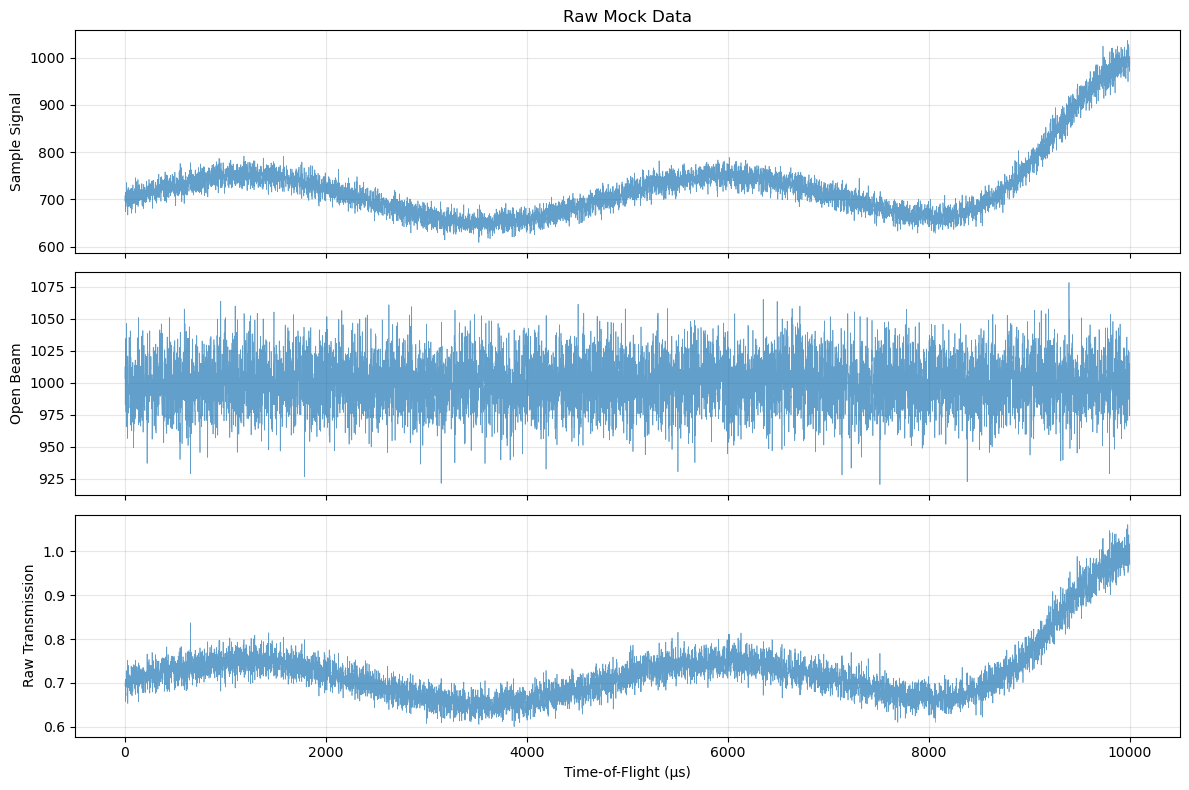

In [3]:
# Plot raw data
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(t, signal, alpha=0.7, linewidth=0.5)
axes[0].set_ylabel('Sample Signal')
axes[0].set_title('Raw Mock Data')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, openbeam, alpha=0.7, linewidth=0.5)
axes[1].set_ylabel('Open Beam')
axes[1].grid(True, alpha=0.3)

axes[2].plot(t, signal/openbeam, alpha=0.7, linewidth=0.5)
axes[2].set_ylabel('Raw Transmission')
axes[2].set_xlabel('Time-of-Flight (µs)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Basic Workflow: Method Chaining

The new FOBI API uses method chaining for a clean, readable workflow:

In [4]:
# Simple one-liner reconstruction
result = (fobi.Workflow
    .load_arrays(signal=signal, openbeam=openbeam, time=t, L=L)
    .interpolate(tmax=tmax, nrep=nrep)
    .convolve(chopper="POLDI", noise_level=0.1)
    .reconstruct())

print("Reconstruction complete!")
print(f"Reconstructed {len(result.time)} spectral points")

Reconstruction complete!
Reconstructed 1000 spectral points


## 3. Visualize Results

The result object has convenient plotting methods:

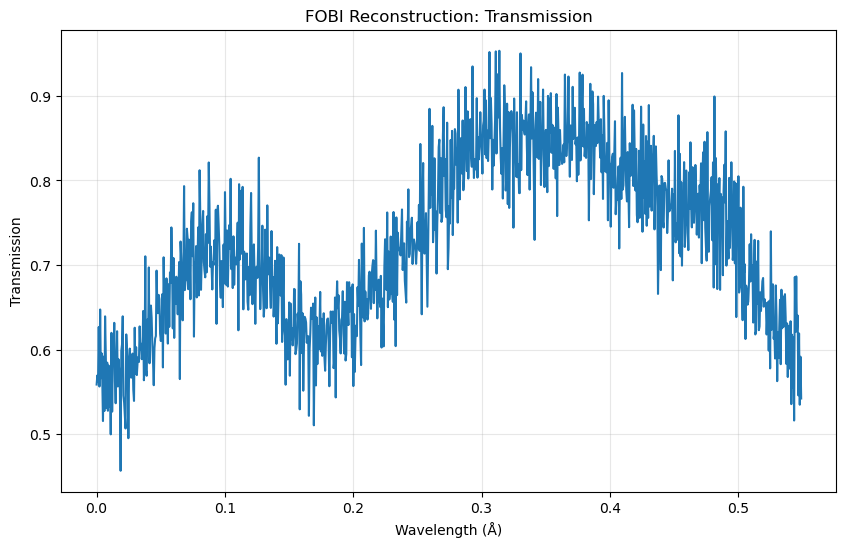

In [6]:
# Plot transmission in wavelength space
result.plot(what="transmission", x_axis="wavelength");

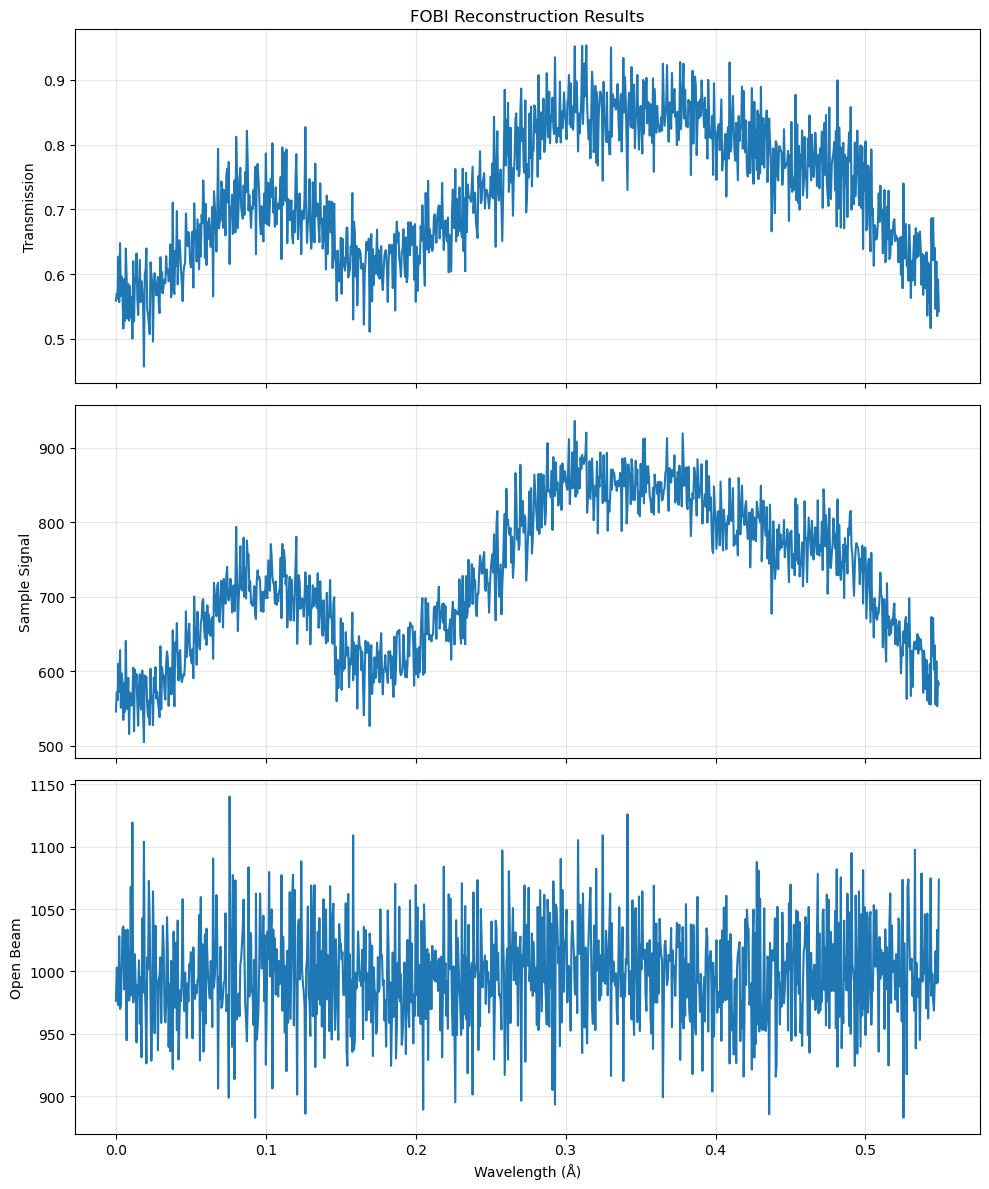

In [7]:
# Plot all results
result.plot(what="all", x_axis="wavelength");

## 4. Compare with True Transmission

Since we generated the data, we can compare the reconstruction with the true transmission:

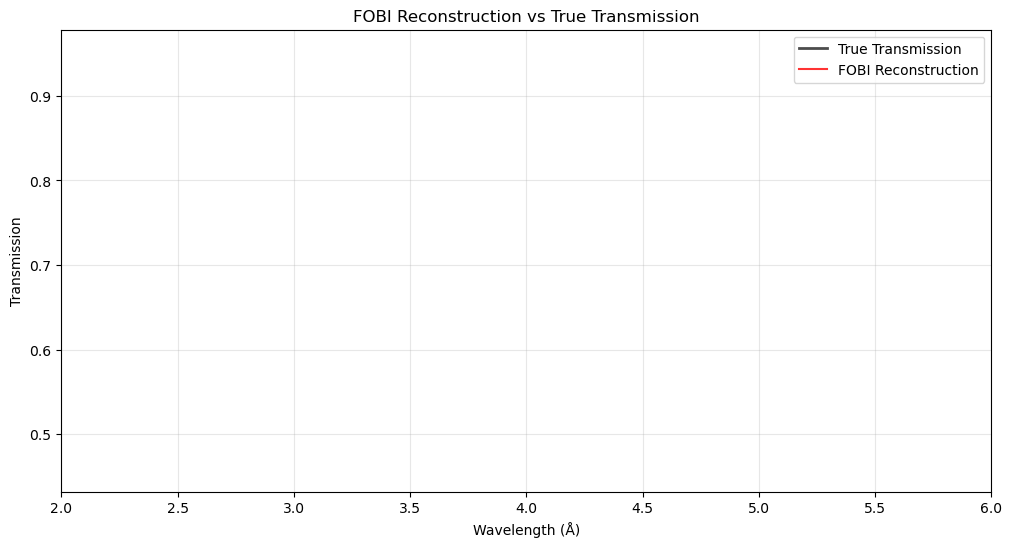

In [8]:
plt.figure(figsize=(12, 6))

# Calculate true transmission on reconstructed wavelength grid
true_wavelength = 3.956 * (t / 1000) / L
true_trans_interp = np.interp(result.wavelength, true_wavelength, true_transmission)

plt.plot(result.wavelength, true_trans_interp, 'k-', linewidth=2, label='True Transmission', alpha=0.7)
plt.plot(result.wavelength, result.transmission, 'r-', linewidth=1.5, label='FOBI Reconstruction', alpha=0.8)

plt.xlabel('Wavelength (Å)')
plt.ylabel('Transmission')
plt.title('FOBI Reconstruction vs True Transmission')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(2, 6)
plt.show()

## 5. Explore Different Parameters

### 5.1 Effect of Noise Level

The `noise_level` parameter controls the Wiener filter regularization:

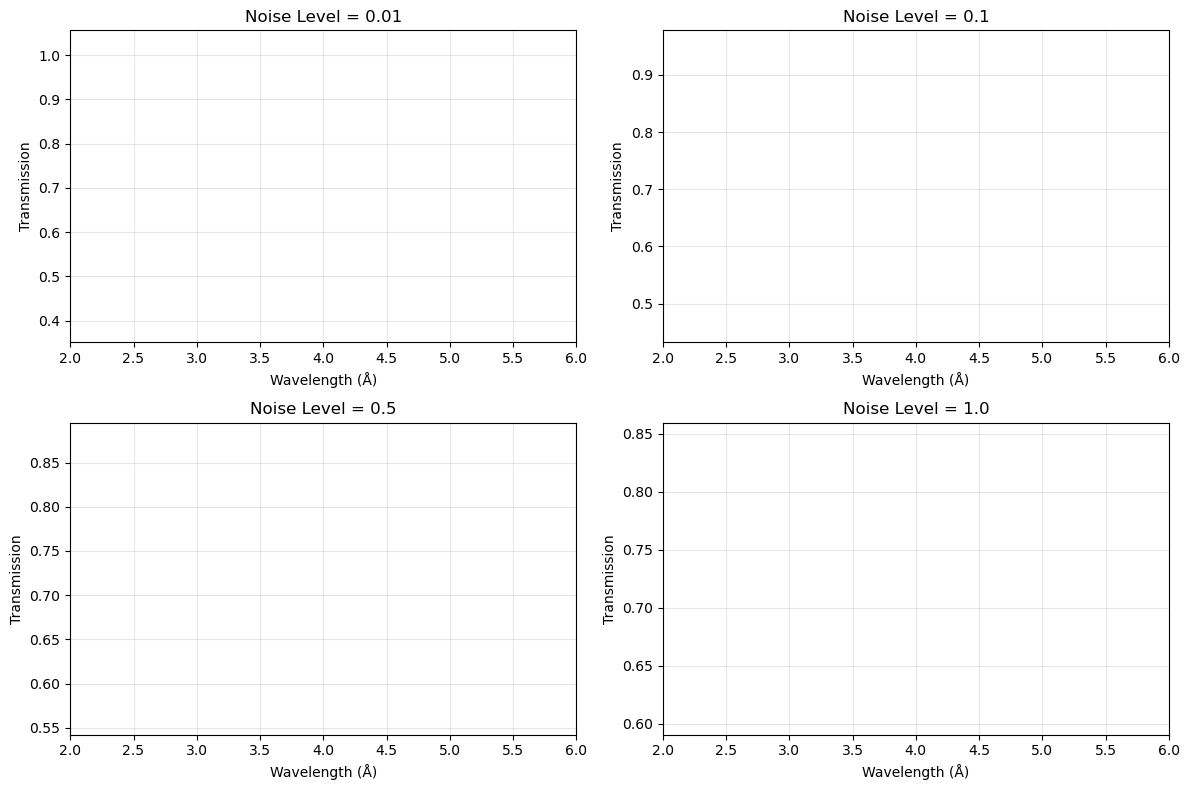

Lower noise_level = sharper features but more noise
Higher noise_level = smoother but may blur edges


In [9]:
noise_levels = [0.01, 0.1, 0.5, 1.0]

plt.figure(figsize=(12, 8))

for i, noise in enumerate(noise_levels, 1):
    result_test = (fobi.Workflow
        .load_arrays(signal=signal, openbeam=openbeam, time=t, L=L)
        .interpolate(tmax=tmax, nrep=nrep)
        .convolve(chopper="POLDI", noise_level=noise)
        .reconstruct())
    
    plt.subplot(2, 2, i)
    plt.plot(result_test.wavelength, result_test.transmission, linewidth=1.5)
    plt.xlabel('Wavelength (Å)')
    plt.ylabel('Transmission')
    plt.title(f'Noise Level = {noise}')
    plt.grid(True, alpha=0.3)
    plt.xlim(2, 6)

plt.tight_layout()
plt.show()

print("Lower noise_level = sharper features but more noise")
print("Higher noise_level = smoother but may blur edges")

### 5.2 Different Chopper Configurations

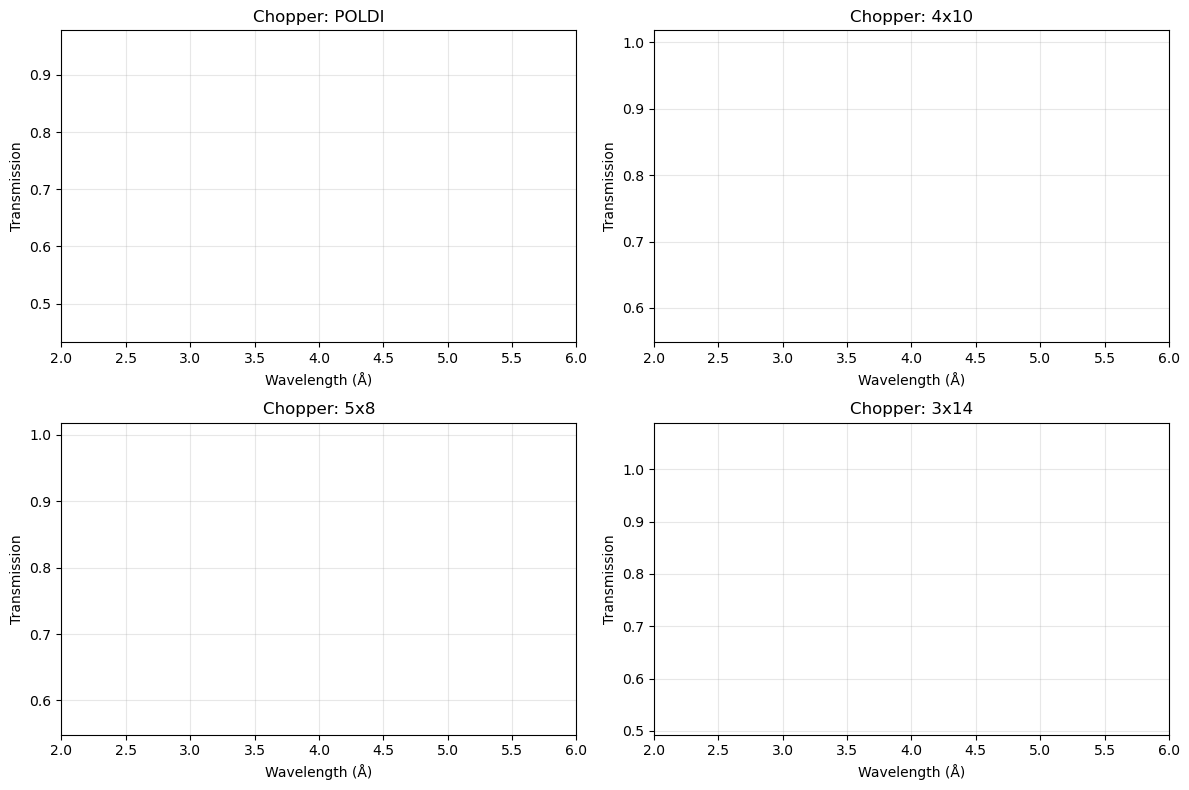

In [10]:
choppers = ["POLDI", "4x10", "5x8", "3x14"]

plt.figure(figsize=(12, 8))

for i, chopper in enumerate(choppers, 1):
    result_test = (fobi.Workflow
        .load_arrays(signal=signal, openbeam=openbeam, time=t, L=L)
        .interpolate(tmax=tmax, nrep=nrep)
        .convolve(chopper=chopper, noise_level=0.1)
        .reconstruct())
    
    plt.subplot(2, 2, i)
    plt.plot(result_test.wavelength, result_test.transmission, linewidth=1.5)
    plt.xlabel('Wavelength (Å)')
    plt.ylabel('Transmission')
    plt.title(f'Chopper: {chopper}')
    plt.grid(True, alpha=0.3)
    plt.xlim(2, 6)

plt.tight_layout()
plt.show()

### 5.3 Frequency Domain Filtering

ValueError: could not broadcast input array from shape (500,) into shape (501,)

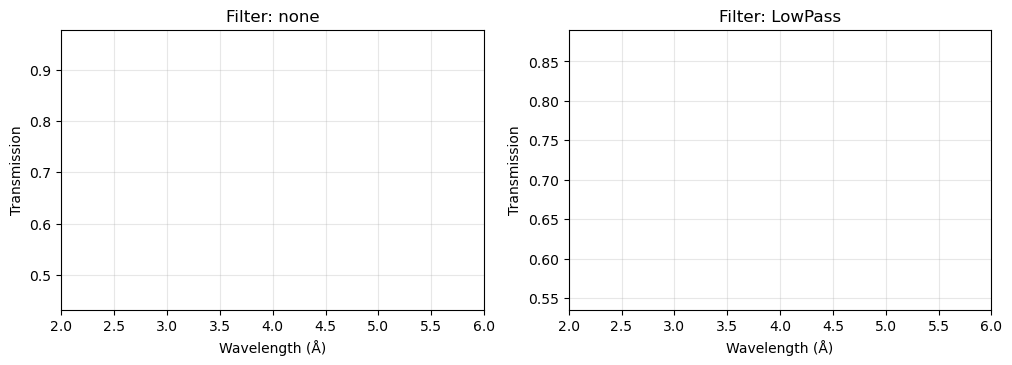

In [11]:
filters = ["none", "LowPass", "LowPassBu", "LowPassGa"]

plt.figure(figsize=(12, 8))

for i, filt in enumerate(filters, 1):
    result_test = (fobi.Workflow
        .load_arrays(signal=signal, openbeam=openbeam, time=t, L=L)
        .interpolate(tmax=tmax, nrep=nrep)
        .convolve(chopper="POLDI", noise_level=0.1, filter_type=filt)
        .reconstruct())
    
    plt.subplot(2, 2, i)
    plt.plot(result_test.wavelength, result_test.transmission, linewidth=1.5)
    plt.xlabel('Wavelength (Å)')
    plt.ylabel('Transmission')
    plt.title(f'Filter: {filt}')
    plt.grid(True, alpha=0.3)
    plt.xlim(2, 6)

plt.tight_layout()
plt.show()

## 6. Loading from CSV Files

For real data, you can load from CSV files:

In [12]:
# Save our mock data to CSV for demonstration
import pandas as pd

signal_df = pd.DataFrame({'time': t, 'signal': signal})
openbeam_df = pd.DataFrame({'time': t, 'signal': openbeam})

signal_df.to_csv('sample_signal.csv', index=False)
openbeam_df.to_csv('sample_openbeam.csv', index=False)

print("Saved mock data to CSV files")

Saved mock data to CSV files


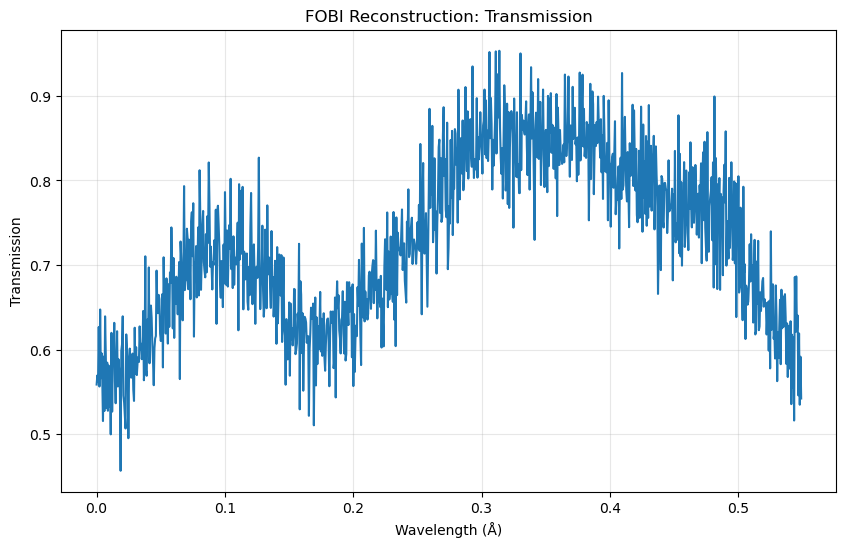

In [14]:
# Load from CSV and reconstruct
result_from_csv = (fobi.Workflow
    .load(signal="sample_signal.csv", openbeam="sample_openbeam.csv", L=L)
    .interpolate(tmax=tmax, nrep=nrep)
    .convolve(chopper="POLDI", noise_level=0.1)
    .reconstruct())

result_from_csv.plot(what="transmission", x_axis="wavelength");

## 7. Saving Results

Results can be saved to CSV or numpy format:

In [16]:
# Save to CSV
result.save('reconstruction_results.csv', format='csv')

# Save to numpy format (preserves all metadata)
result.save('reconstruction_results.npy', format='npy');

Results saved to reconstruction_results.csv
Results saved to reconstruction_results.npy


In [17]:
# Load saved results
loaded_data = np.load('reconstruction_results.npy', allow_pickle=True).item()

print("Loaded data keys:", loaded_data.keys())
print("\nMetadata:")
for key, value in loaded_data['metadata'].items():
    print(f"  {key}: {value}")

Loaded data keys: dict_keys(['time', 'transmission', 'signal', 'openbeam', 'wavelength', 'metadata'])

Metadata:
  chopper: POLDI
  noise_level: 0.1
  filter_type: none
  L: 9
  roll: 0


## 8. Complete Example: Iron Powder

Let's create a more realistic example with multiple Bragg edges (iron powder):

In [18]:
def iron_transmission(wavelength):
    """Create realistic iron powder transmission with multiple Bragg edges."""
    # Iron BCC structure edges (in Angstroms)
    edges = [
        (2.027, 0.10, 0.25),  # (110)
        (2.866, 0.12, 0.20),  # (200)
        (4.050, 0.15, 0.30),  # (211)
    ]
    
    transmission = np.ones_like(wavelength) * 0.6
    
    for pos, width, height in edges:
        transmission += height / (1 + np.exp(-(wavelength - pos) / width))
    
    return transmission

# Generate iron powder data
t_iron, signal_iron, openbeam_iron, _ = generate_mock_data(L=9, tmax=10000, nrep=8, noise_std=0.03)
wavelength_iron = 3.956 * (t_iron / 1000) / 9
transmission_iron = iron_transmission(wavelength_iron)
signal_iron = transmission_iron * openbeam_iron + np.random.randn(len(t_iron)) * 0.02 * openbeam_iron

# Reconstruct
result_iron = (fobi.Workflow
    .load_arrays(signal=signal_iron, openbeam=openbeam_iron, time=t_iron, L=9)
    .interpolate(tmax=10000, nrep=8)
    .convolve(chopper="POLDI", noise_level=0.1, filter_type="LowPassGa")
    .reconstruct())

# Plot
plt.figure(figsize=(14, 6))
plt.plot(result_iron.wavelength, result_iron.transmission, linewidth=2, label='FOBI Reconstruction')
plt.axvline(2.027, color='r', linestyle='--', alpha=0.5, label='Fe (110)')
plt.axvline(2.866, color='g', linestyle='--', alpha=0.5, label='Fe (200)')
plt.axvline(4.050, color='b', linestyle='--', alpha=0.5, label='Fe (211)')
plt.xlabel('Wavelength (Å)', fontsize=12)
plt.ylabel('Transmission', fontsize=12)
plt.title('FOBI Reconstruction: Iron Powder', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim(1.5, 5)
plt.show()

ValueError: could not broadcast input array from shape (500,) into shape (501,)

## Summary

This tutorial demonstrated:

1. **Simple API**: Method chaining for clean, readable workflows
2. **Flexible Loading**: Load from CSV files or numpy arrays
3. **Parameter Exploration**: Easy to test different reconstruction settings
4. **Built-in Visualization**: Convenient plotting methods
5. **Data Export**: Save results in CSV or numpy format

### Key Workflow Steps:

```python
result = (fobi.Workflow
    .load(signal="data.csv", openbeam="openbeam.csv", L=9)
    .interpolate(tmax=10000, nrep=8)
    .convolve(chopper="POLDI", noise_level=0.1)
    .reconstruct()
    .plot())
```

### Next Steps:

- Explore different chopper configurations
- Optimize noise_level for your data
- Try different frequency domain filters
- Analyze Bragg edge positions and widths
- See the Streamlit app for interactive exploration!